In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [5]:
topp,bottomm,rightt,leftt=[],[],[],[]
pp=[]


Detected 12 distinct paper fragments.


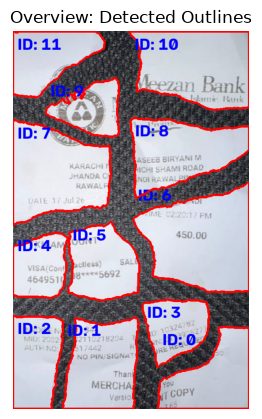

In [7]:

isolated_pieces_list = []
def display_detected_fragments(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return
    
    # Convert from BGR to RGB for correct Matplotlib color display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    
    # 2. Preprocess to separate paper pieces from the dark background
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Otsu's thresholding to separate white paper from dark gaps
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Clean up noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # 3. Find individual contours of each piece of paper
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter out tiny noise (keep only fragments larger than 1% of the total image area)
    min_area = (h * w) * 0.01  
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]
    
    print(f"Detected {len(fragments)} distinct paper fragments.")
    
    # 4. Draw bounding highlights on a copy of the original image
    highlighted_img = img_rgb.copy()
    
    # 5. Extract and plot each individual fragment
    num_fragments = len(fragments)
    
    # Create a grid layout to plot individual pieces side-by-side
    # We add +1 to the columns to show the overview image first
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols
    
    plt.figure(figsize=(15, rows * 4))
    
    # Plot 1: Show all detected areas on the original image
    for idx, contour in enumerate(fragments):
        cv2.drawContours(highlighted_img, [contour], -1, (255, 0, 0), 4) # Blue outline
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(highlighted_img, f"ID: {idx}", (x + 10, y + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")
    
    # Plot remaining subplots: Individual cropped pieces
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Isolate the current piece
        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        
        # Crop to its bounding box boundaries
        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y:y+ph, x:x+pw]
        
        # plt.subplot(rows, cols, idx + 2)
        # plt.imshow(cropped_piece)
        # plt.title(f"Fragment ID: {idx}")
        # plt.axis("off")
        isolated_pieces_list.append(cropped_piece)  # Store the isolated piece for later use

        
    plt.tight_layout()
    plt.show()

display_detected_fragments(r'D:\PythonProject1\Intern\Images\img97.png')

Top :    TORN (variance: 45.93px)
Bottom : STRAIGHT (variance: 0.00px)
Left :   TORN (avg: 57.13px)
Right :  TORN (avg: 4.35px)
TOP Distances[150, 146, 139, 127, 125, 124, 123, 122, 121, 120, 118, 116, 115, 115, 114, 115, 115, 116, 116, 116, 116, 115, 114, 113, 113, 112, 112, 111, 110, 110, 109, 109, 109, 108, 108, 108, 106, 105, 104, 104, 104, 103, 103, 103, 102, 102, 101, 101, 101, 101, 101, 101, 100, 100, 99, 99, 99, 99, 99, 99, 99, 98, 98, 98, 97, 97, 97, 97, 96, 96, 96, 96, 96, 96, 95, 95, 95, 95, 94, 94, 94, 94, 94, 93, 93, 93, 93, 93, 92, 92, 91, 91, 91, 90, 89, 89, 88, 88, 87, 86, 86, 85, 85, 85, 84, 83, 82, 82, 81, 80, 78, 77, 76, 75, 74, 73, 72, 71, 69, 63, 61, 59, 57, 56, 55, 52, 50, 47, 45, 42, 9, 7, 7, 6, 6, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 6, 6, 6, 6, 7, 7, 7, 7, 8]
LEFT Distances [140, 138, 136, 136, 135, 135, 136, 136, 136, 136, 136, 137, 137,

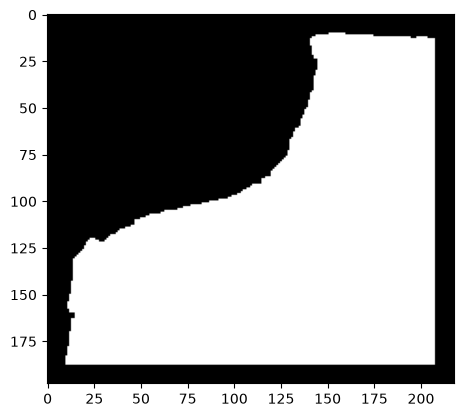

Top :    TORN (variance: 42.12px)
Bottom : TORN (variance: 27.91px)
Left :   TORN (avg: 16.65px)
Right :  TORN (avg: 3.39px)
TOP Distances[189, 187, 185, 181, 164, 152, 147, 127, 125, 120, 118, 109, 107, 105, 104, 100, 98, 96, 92, 80, 78, 73, 71, 70, 67, 9, 7, 7, 6, 6, 6, 6, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 12, 12, 12, 13, 13, 13, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 17, 17, 18, 18, 18, 18, 18, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 12, 12, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 9, 8, 8, 7, 6, 6, 5, 5, 4, 5, 5, 5, 5, 6, 6, 7, 9, 17]
BOTTOM Distances[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,

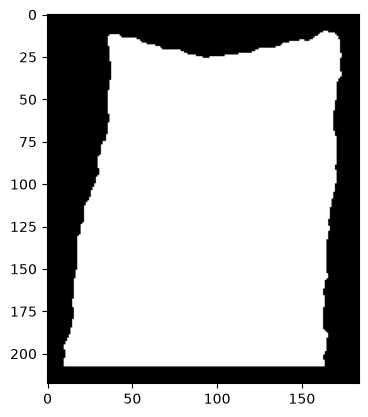

Top :    TORN (variance: 2.14px)
Bottom : TORN (variance: 40.95px)
Left :   STRAIGHT (avg: 0.00px)
Right :  TORN (avg: 12.62px)
TOP Distances[5, 5, 5, 5, 5, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 9, 9, 9, 10, 10, 11, 11, 12, 12, 13, 14, 14, 14, 14, 15, 15]
BOTTOM Distances[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 28, 30, 46, 48, 51, 52, 53, 55, 82, 83, 101, 103, 105, 110, 112, 116, 124, 128, 129, 134, 145, 148, 169]
RIGHT Distances[109, 51, 23, 21, 18, 16, 14, 12, 11, 7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5

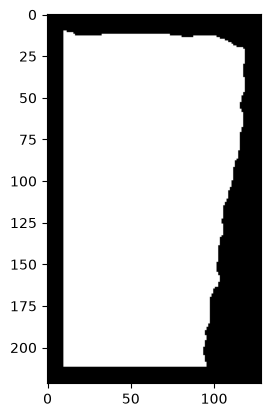

Top :    TORN (variance: 4.44px)
Bottom : TORN (variance: 28.34px)
Left :   TORN (avg: 11.26px)
Right :  TORN (avg: 33.58px)
TOP Distances[15, 14, 13, 13, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 7, 6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 10, 10, 11, 16, 17, 21, 25, 33, 40]
BOTTOM Distances[125, 120, 118, 116, 112, 110, 99, 97, 97, 96, 83, 81, 76, 68, 63, 61, 60, 59, 58, 56, 50, 49, 47, 41, 39, 37, 35, 19, 17, 14, 8, 6, 5, 5, 5, 5, 6, 7, 8, 9, 10, 10, 11, 11, 11, 12, 12, 12, 12, 12, 12, 13, 14, 15, 16, 17, 17, 18, 19, 20, 21, 21, 21, 21, 22, 24, 25, 26, 26, 27, 27, 27, 28, 29, 30, 30, 31, 31, 31, 31, 32, 33, 33, 34, 34, 34, 35, 35, 35, 35, 35, 36, 36, 36, 36,

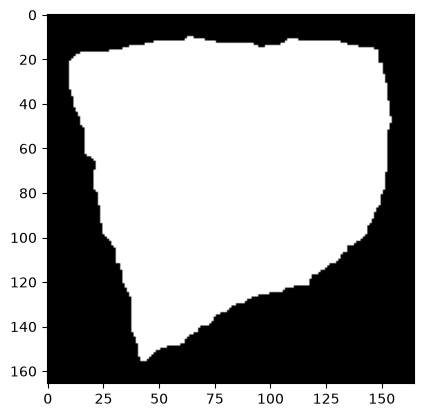

Top :    TORN (variance: 9.83px)
Bottom : TORN (variance: 21.22px)
Left :   TORN (avg: 23.24px)
Right :  TORN (avg: 6.56px)
TOP Distances[35, 34, 34, 33, 32, 32, 31, 31, 31, 31, 31, 31, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 29, 29, 28, 28, 27, 27, 26, 26, 25, 25, 25, 24, 23, 22, 21, 20, 19, 19, 19, 18, 18, 17, 17, 17, 17, 17, 17, 17, 16, 16, 15, 15, 15, 15, 14, 14, 13, 12, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 5, 5, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 7, 8, 9, 10, 10, 11, 12, 12, 13, 13, 14, 14]
BOTTOM Distances[10, 10, 10, 11, 11, 10, 10, 10, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 6, 6, 6, 7, 7, 8, 8, 8, 9, 10, 10, 10, 10, 10, 11, 11, 11, 13, 16, 19, 22, 23, 23, 24, 25, 27, 28, 30, 41, 44, 58, 59, 62, 127, 129, 131]
LEFT Distances [94,

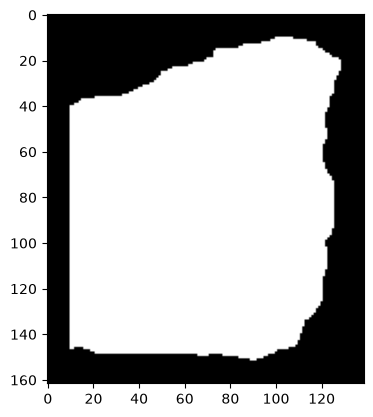

Top :    TORN (variance: 24.14px)
Bottom : TORN (variance: 8.11px)
Left :   TORN (avg: 20.61px)
Right :  TORN (avg: 21.63px)
TOP Distances[145, 45, 29, 27, 27, 26, 26, 25, 25, 25, 24, 24, 24, 24, 24, 24, 24, 24, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 21, 21, 21, 21, 21, 21, 21, 20, 19, 19, 18, 17, 17, 16, 16, 15, 15, 14, 14, 14, 14, 14, 13, 13, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 13, 13, 13, 13, 12, 11, 11, 10, 10, 9, 9, 8, 7, 6, 5, 5, 4, 4, 5, 5, 6, 11, 12, 14, 15, 18, 21, 25, 26, 27, 28, 29, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 43, 43, 43, 44, 46, 47, 47, 48, 48, 49, 50, 50, 52, 53, 54, 55, 56, 58, 59, 60, 62, 64, 65, 66, 70, 72, 74, 77, 84, 86, 89, 91, 94]
BOTTOM Distances[23, 22, 21, 21, 21, 21, 21, 21, 21, 21, 20, 19, 18, 18, 17, 17, 16, 16, 16, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 12, 12, 12, 12, 11, 11, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 7, 7, 7,

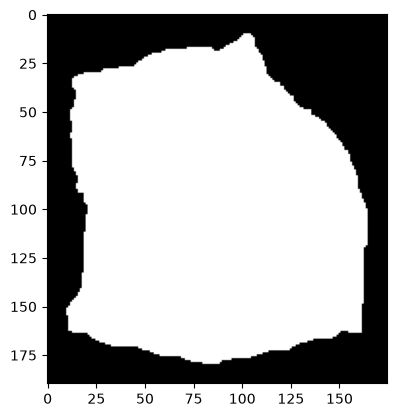

Top :    TORN (variance: 18.61px)
Bottom : TORN (variance: 43.61px)
Left :   TORN (avg: 68.52px)
Right :  TORN (avg: 2.27px)
TOP Distances[83, 82, 81, 80, 80, 79, 79, 78, 78, 77, 76, 75, 74, 74, 73, 72, 72, 71, 71, 71, 71, 71, 71, 70, 69, 69, 68, 68, 67, 67, 67, 66, 66, 65, 64, 63, 63, 63, 62, 62, 61, 61, 61, 60, 60, 59, 59, 58, 58, 58, 58, 57, 57, 57, 57, 57, 57, 57, 57, 56, 56, 56, 56, 56, 56, 56, 56, 55, 55, 55, 56, 56, 57, 57, 57, 57, 56, 56, 56, 56, 56, 56, 56, 55, 53, 51, 50, 50, 49, 49, 49, 49, 49, 48, 47, 46, 46, 45, 46, 46, 47, 47, 47, 47, 46, 46, 47, 48, 48, 48, 48, 48, 46, 46, 45, 44, 44, 43, 43, 42, 42, 42, 42, 41, 41, 41, 41, 41, 40, 40, 39, 39, 39, 38, 39, 39, 39, 39, 39, 39, 39, 38, 37, 37, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 35, 35, 34, 34, 34, 34, 33, 33, 33, 33, 33, 32, 32, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 30, 30, 29, 29, 29, 29, 28, 28, 28, 28, 28, 28, 27, 27, 26, 25, 24, 24, 23, 22, 2

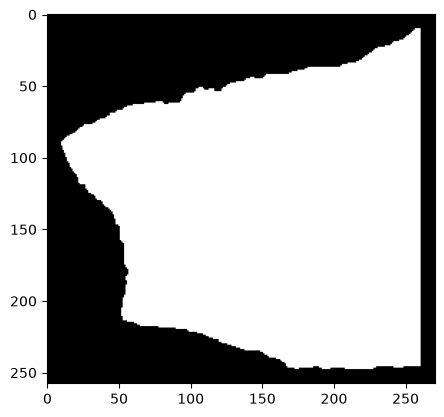

Top :    TORN (variance: 21.68px)
Bottom : TORN (variance: 16.23px)
Left :   STRAIGHT (avg: 0.00px)
Right :  TORN (avg: 69.36px)
TOP Distances[5, 4, 4, 4, 4, 4, 4, 5, 5, 6, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 8, 9, 9, 10, 11, 11, 11, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 14, 14, 14, 14, 13, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 15, 15, 15, 15, 15, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 19, 20, 21, 22, 22, 22, 23, 23, 24, 24, 24, 24, 24, 24, 24, 25, 25, 26, 26, 26, 26, 26, 27, 27, 28, 29, 30, 30, 31, 31, 32, 33, 33, 34, 35, 35, 35, 35, 35, 36, 36, 37, 37, 38, 38, 38, 39, 39, 40, 41, 41, 42, 42, 43, 43, 44, 44, 44, 44, 45, 45, 46, 47, 47, 48, 48, 49, 49, 50, 50, 51, 51, 52, 53, 53, 54, 54, 55, 56, 56, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 58, 58, 58, 58, 58, 58, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 60, 60, 61, 61, 61, 61, 61, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 59, 59, 60, 63, 74, 115, 119]
BOTTOM Distances[5, 5, 6, 7, 8, 

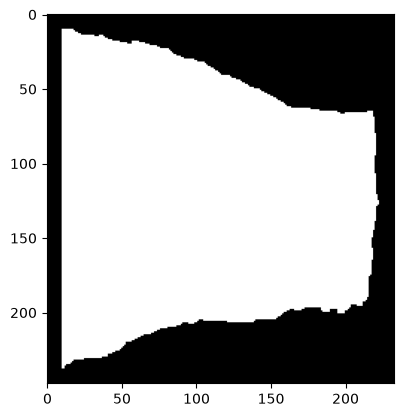

Top :    TORN (variance: 8.59px)
Bottom : TORN (variance: 30.82px)
Left :   TORN (avg: 3.22px)
Right :  TORN (avg: 81.82px)
TOP Distances[11, 8, 7, 6, 6, 6, 5, 5, 4, 4, 4, 4, 4, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 8, 8, 9, 9, 9, 10, 10, 11, 11, 11, 12, 12, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 16, 16, 16, 16, 16, 17, 17, 17, 18, 18, 18, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 23, 23, 24, 25, 25, 25, 26, 26, 26, 27, 27, 28, 28, 28, 28, 28, 29, 29, 29, 29, 29, 29, 29, 29, 29, 30, 31, 31, 31, 31, 30, 30, 30, 29, 29, 29, 29, 29, 29, 28, 28, 28, 28, 28, 28, 28, 28, 27, 27, 27, 27, 27, 26, 26, 26, 26, 26, 25, 26, 26, 26, 26, 26, 26, 25, 25, 25, 25, 25, 26, 26, 26, 26, 26, 26, 26, 26, 26, 25, 25, 25, 25, 25, 25, 24, 24, 24, 23, 23, 23, 23, 

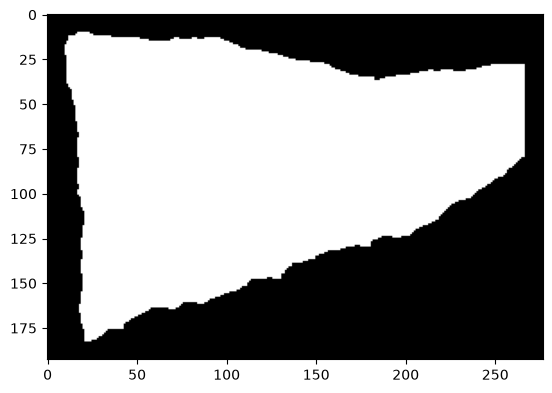

Top :    TORN (variance: 20.69px)
Bottom : TORN (variance: 15.67px)
Left :   TORN (avg: 40.84px)
Right :  TORN (avg: 1.89px)
TOP Distances[73, 71, 70, 68, 68, 67, 66, 65, 64, 63, 62, 61, 61, 60, 60, 61, 61, 62, 62, 62, 62, 62, 61, 61, 60, 59, 58, 58, 57, 56, 55, 54, 53, 51, 51, 50, 50, 49, 49, 50, 54, 56, 56, 57, 57, 45, 43, 42, 41, 40, 40, 40, 40, 39, 39, 39, 39, 40, 44, 46, 47, 37, 35, 35, 34, 34, 34, 34, 34, 33, 33, 33, 32, 32, 33, 40, 41, 48, 48, 36, 34, 30, 29, 28, 28, 28, 28, 27, 26, 26, 26, 25, 25, 24, 21, 20, 19, 19, 18, 18, 17, 16, 14, 14, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 8, 8, 7, 7, 7, 7, 6, 5, 4, 4, 4, 4, 5, 6, 9, 10, 11, 16, 19]
BOTTOM Distances[54, 53, 53, 52, 52, 51, 50, 49, 49, 48, 48, 48, 47, 47, 47, 46, 46, 46, 46, 45, 44, 43, 42, 42, 41, 41, 41, 41, 41, 41, 41, 40, 40, 40, 40, 39, 38, 37, 37, 37, 37, 36, 34, 34, 34, 34, 34, 33, 33, 32, 32, 31, 31, 30, 30, 29, 28

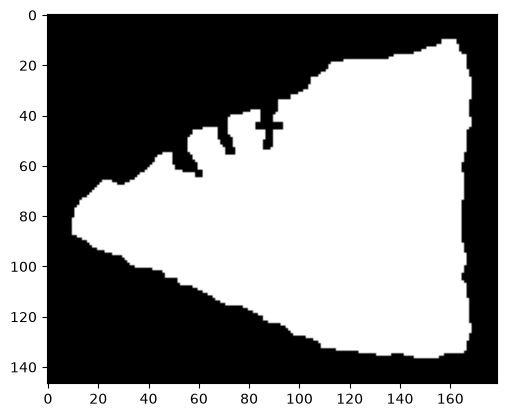

Top :    STRAIGHT (variance: 0.00px)
Bottom : TORN (variance: 34.92px)
Left :   TORN (avg: 48.35px)
Right :  TORN (avg: 7.76px)
BOTTOM Distances[168, 166, 165, 164, 164, 163, 162, 161, 160, 159, 158, 157, 156, 57, 45, 44, 44, 44, 44, 45, 46, 47, 47, 47, 48, 48, 48, 49, 49, 49, 49, 49, 48, 48, 48, 48, 47, 47, 47, 47, 46, 46, 46, 45, 45, 45, 45, 45, 46, 45, 45, 44, 44, 44, 44, 44, 44, 44, 43, 43, 42, 42, 41, 40, 40, 39, 39, 39, 39, 39, 39, 39, 39, 39, 40, 40, 39, 39, 39, 39, 39, 39, 39, 38, 38, 37, 37, 37, 37, 37, 37, 38, 37, 37, 37, 37, 37, 37, 37, 37, 37, 36, 35, 35, 34, 34, 34, 34, 33, 32, 29, 28, 28, 28, 28, 28, 27, 27, 26, 26, 26, 26, 25, 25, 24, 24, 23, 23, 23, 23, 23, 23, 22, 22, 22, 22, 21, 21, 20, 20, 20, 20, 20, 20, 19, 19, 18, 18, 17, 17, 16, 15, 15, 14, 13, 13, 13, 12, 12, 11, 10, 10, 10, 9, 9, 8, 8, 8, 7, 7, 7, 7, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9

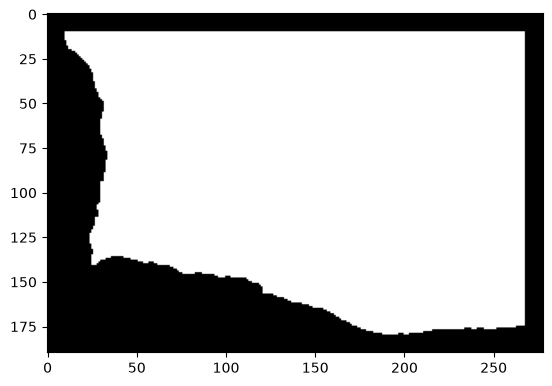

Top :    TORN (variance: 3.51px)
Bottom : TORN (variance: 36.84px)
Left :   TORN (avg: 5.31px)
Right :  TORN (avg: 49.86px)
TOP Distances[5, 4, 4, 4, 5, 6, 6, 6, 6, 6, 6, 6, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 6, 7, 7, 8, 8, 9, 9, 10, 11, 13, 14, 16, 17, 18, 20, 22, 23, 24, 26]
BOTTOM Distances[9, 9, 9, 10, 11, 10, 10, 10, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 6, 7, 7, 8, 8, 9, 11, 12, 14, 17, 18, 19, 20, 21, 22, 23, 23, 25, 

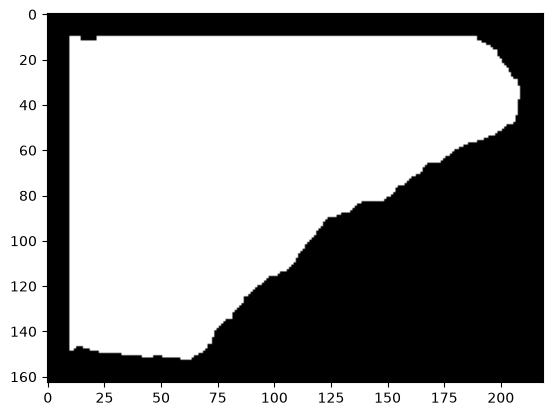

In [ ]:
ccc=-1
for  current_piece in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        print(f"TOP Distances{distances_top}")

        topp.append(distances_top)

        
    else:
        topp.append(np.nan)

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        print(f"BOTTOM Distances{distances_bottom}")
        
        bottomm.append(distances_bottom)
    else:
        bottomm.append(np.nan)

    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        print(f"LEFT Distances {distances_left}")
       
        leftt.append(distances_left)
    else:
        leftt.append(np.nan)

    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        
        print(f"RIGHT Distances{distances_right}")
      
        rightt.append(distances_right)
        

    else:
        rightt.append(np.nan)
    ccc+=1
    print(ccc)
    pp.append(thresh)
    plt.imshow(thresh, cmap='gray')
    plt.show()




In [13]:
side1 = rightt[0]
side2 = leftt[1]
print(side1)
print(side2)
th = 0.82
tr = 12

edge1 = np.array(side1 if len(side1) > 2*tr else side1, dtype=float)
edge2 = np.array(side2 if len(side2) > 2*tr else side2, dtype=float)

x1 = np.arange(len(edge1))
slope1, intercept1 = np.polyfit(x1, edge1, 1)
detrended1 = edge1 - (slope1 * x1 + intercept1)
roughness1 = np.std(detrended1)

x2 = np.arange(len(edge2))
slope2, intercept2 = np.polyfit(x2, edge2, 1)
detrended2 = edge2 - (slope2 * x2 + intercept2)
roughness2 = np.std(detrended2)

if roughness1 < 1.2 or roughness2 < 1.2:
    print("NOT MATCHED ")
  

else:
    norm1 = (edge1 - np.min(edge1)) / (np.max(edge1) - np.min(edge1) + 1e-6)
    norm2 = (edge2 - np.min(edge2)) / (np.max(edge2) - np.min(edge2) + 1e-6)

    if len(norm1) < len(norm2):
        shorter, longer = norm1, norm2
        is1_shorter = True
    else:
        shorter, longer = norm2, norm1
        is1_shorter = False
        
    s_len, l_len = len(shorter), len(longer)

    best_score = 0.0
    best_offset = 0

    for direction in ["Forward", "Reversed"]:
        test_shorter = shorter if direction == "Forward" else shorter[::-1]
        
        for offset in range(l_len - s_len + 1):
            segment = longer[offset:offset + s_len]
            
            dist_direct = np.mean(np.abs(test_shorter - segment))
            score_direct = 1.0 - dist_direct
            
            dist_comp = np.mean(np.abs(test_shorter - (1.0 - segment)))
            score_comp = 1.0 - dist_comp
            
            if score_direct > best_score:
                best_score = score_direct
                best_offset = offset if is1_shorter else -offset
                
            if score_comp > best_score:
                best_score = score_comp
                best_offset = offset if is1_shorter else -offset

    confidence = best_score * 100

    if best_score >= th:
        print("MATCHED ")
        print(f"Confidence Score: {confidence:.2f}%")
    else:
        print("NOT MATCHED ")
        print(f"Confidence Score: {confidence:.2f}%")



[39, 10, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
[157, 33, 31, 31, 30, 30, 30, 30, 31, 31, 31, 31, 31, 31, 31, 31, 31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 31, 31, 31, 31, 31, 31, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 31, 31, 31, 31, 31, 31, 31, 30, 30, 30, 30, 30, 30, 30, 29, 29, 29, 28, 27, 27, 26, 26, 26, 26, 26, 25, 25, 24, 24, 24, 24, 24, 25, 25, 25, 25, 25, 24, 24, 23, 23, 23, 23, 22, 22, 21, 21, 20, 20, 20, 20, 19, 18, 18, 17, 17, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 1

In [14]:
def get_thresh(img):
    return cv2.threshold(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY)[1]

def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y:-min_y+hA, -min_x:-min_x+wA][threshA > 0] = imgA[threshA > 0]
    canvas[dy-min_y:dy-min_y+hB, dx-min_x:dx-min_x+wB][threshB > 0] = imgB[threshB > 0]
    return canvas

def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (int(p2[0].max()) - int(p3[0].max())) if ref == "bottom" else (int(p2[0].min()) - int(p3[0].min()))
    
    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {r: np.max(x2[y2 == r]) for r in range(np.min(p2[0]), np.max(p2[0]) + 1) if len(x2[y2 == r]) > 0}
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {r: np.min(x3[y3 == r]) for r in range(np.min(p3[0]), np.max(p3[0]) + 1) if len(x3[y3 == r]) > 0}
    
    dx = int(np.percentile([b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90))
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)

def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)
    
    dx = (np.min(x0) if side == "left" else np.max(x0)) - (np.min(x1) if side == "left" else np.max(x1))
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}
    
    dy = int(np.percentile([bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92))
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)

def ad_stitch(img_base, img_patch):
    m_b = ((cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)
    m_p = ((cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)
    
    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out, dist_in = cv2.distanceTransform(~m_b, cv2.DIST_L2, 5), cv2.distanceTransform(m_b, cv2.DIST_L2, 5)
    
    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float('inf')
    
    for dy in range(-int(h_b * 0.8), int(h_b * 0.8)):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue
                
            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]
            
            touching = np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            deep = np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            score = -touching + (4.0 * deep)
            
            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    canvas = np.zeros((max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox), 3), dtype=np.uint8)
    canvas[oy:oy+h_b, ox:ox+w_b] = img_base
    canvas[best_dy+oy : best_dy+oy+h_p, best_dx+ox : best_dx+ox+w_p][m_p == 255] = img_patch[m_p == 255]
    return canvas

def detect_flat_edges(piece1, piece2):
    sides = []
    for img in [piece1, piece2]:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
        _, thresh = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
        y, x = np.where(thresh == 255)
        if len(y) == 0:
            sides.append(None)
            continue
            
        ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
        w, h = xmax - xmin + 1, ymax - ymin + 1
        mw, mh = int(w * 0.1), int(h * 0.1)
        
        flatness = {}
        configs = [
            ("top", x, y, xmin, xmax, mw, w, np.min),
            ("bottom", x, y, xmin, xmax, mw, w, np.max),
            ("left", y, x, ymin, ymax, mh, h, np.min),
            ("right", y, x, ymin, ymax, mh, h, np.max)
        ]
        
        for name, axis, target, start, end, margin, size, func in configs:
            profile = [func(target[axis == val]) for val in range(start + margin, end - margin + 1) if np.any(axis == val)]
            if len(profile) > 0.5 * size:
                flatness[name] = np.std(profile)

        detected_side = None
        if flatness:
            best_side, best_std = min(flatness.items(), key=lambda x: x[1])
            if best_std < 1.5:
                detected_side = best_side
        sides.append(detected_side)
    return sides[0], sides[1]

In [ ]:
can=isolated_pieces_list[2]
can = stitch_by_edge(can, isolated_pieces_list[1], ref='bottom')
can1 = ad_stitch(isolated_pieces_list[0], isolated_pieces_list[3])
can = stitch_by_edge(can,can1, ref='bottom')
can = stitch_by_margin( isolated_pieces_list[4],can, side='left')
can1=ad_stitch( isolated_pieces_list[6],isolated_pieces_list[5])
can=ad_stitch(can,can1)
can = stitch_by_margin( isolated_pieces_list[7],can, side='left')
can=ad_stitch(can, isolated_pieces_list[9])
can = stitch_by_margin( isolated_pieces_list[11],can, side='left')
can = stitch_by_margin( isolated_pieces_list[8],can, side='right')
can = stitch_by_margin( isolated_pieces_list[10],can, side='right')


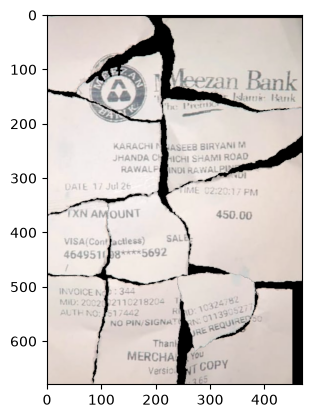

In [ ]:


plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
# positions = isolated_pieces_list

# can = positions[0]

# for i in range(1, len(positions)):
#     next_piece = positions[i]
#     side1, side2 = detect_flat_edges(can, next_piece)
    
#     if side1 == side2 and side1 is not None:
#         if side1 in ['bottom', 'top']:
#             can = stitch_by_edge(can, next_piece, ref=side1)
#         elif side1 in ['left', 'right']:
#             can = stitch_by_margin(can, next_piece, side=side1)
#     else:
#         can = ad_stitch(can, next_piece)
#     plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
#     plt.show()

# plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
# plt.show()

Detected 18 distinct paper fragments.


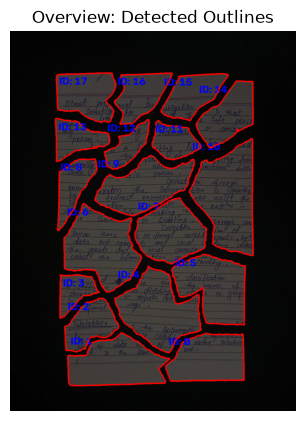

KeyboardInterrupt: 

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

isolated_pieces_list = []

def display_detected_fragments(image_path):
    global isolated_pieces_list
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None
    
    # Convert from BGR to RGB for correct Matplotlib color display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    
    # 2. Preprocess to separate paper pieces from the dark background
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Otsu's thresholding to separate white paper from dark gaps
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Clean up noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # 3. Find individual contours of each piece of paper
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter out tiny noise (keep only fragments larger than 1% of the total image area)
    min_area = (h * w) * 0.009
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]
    
    print(f"Detected {len(fragments)} distinct paper fragments.")
    
    highlighted_img = img_rgb.copy()
    num_fragments = len(fragments)
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols
    
    plt.figure(figsize=(15, rows * 4))
    
    for idx, contour in enumerate(fragments):
        cv2.drawContours(highlighted_img, [contour], -1, (255, 0, 0), 4) # Blue outline
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(highlighted_img, f"ID: {idx}", (x + 10, y + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")
    
    temporary_storage = []
    # Plot remaining subplots: Individual cropped pieces
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Isolate the current piece
        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        
        # Crop to its bounding box boundaries
        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y:y+ph, x:x+pw]
        
        # CRITICAL FIX: Save the cropped image alongside its structural (x, y) origin coordinates
        temporary_storage.append({
            'img': cropped_piece,
            'orig_x': x,
            'orig_y': y
        })
        
    plt.tight_layout()
    plt.show()
    
    return temporary_storage, w

# --- SORTING FUNCTION ---

def sort_pieces_bottom_up_column_wise(fragment_data, total_width, col_width_ratio=0.25):
    """
    Groups fragments into logical vertical columns based on their true origin X coordinate.
    Sorts columns from Left to Right, and fragments inside each column from Bottom to Top.
    """
    column_band_width = total_width * col_width_ratio
    columns = {}
    
    # Group pieces into vertical column buckets
    for entry in fragment_data:
        col_idx = int(entry['orig_x'] // column_band_width)
        if col_idx not in columns:
            columns[col_idx] = []
        columns[col_idx].append(entry)
        
    sorted_pieces = []
    
    # Iterate through column index structures sorted Left to Right
    for col in sorted(columns.keys()):
        column_group = columns[col]
        
        # Sort column elements from Bottom to Top (descending order of structural Y)
        column_group.sort(key=lambda item: item['orig_y'], reverse=True)
        
        for item in column_group:
            sorted_pieces.append(item['img'])
            
    return sorted_pieces

# --- STITCHING CORE LOGIC ---

def get_thresh(img):
    return cv2.threshold(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY)[1]

def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y:-min_y+hA, -min_x:-min_x+wA][threshA > 0] = imgA[threshA > 0]
    canvas[dy-min_y:dy-min_y+hB, dx-min_x:dx-min_x+wB][threshB > 0] = imgB[threshB > 0]
    return canvas

def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (int(p2[0].max()) - int(p3[0].max())) if ref == "bottom" else (int(p2[0].min()) - int(p3[0].min()))
    
    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {r: np.max(x2[y2 == r]) for r in range(np.min(p2[0]), np.max(p2[0]) + 1) if len(x2[y2 == r]) > 0}
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {r: np.min(x3[y3 == r]) for r in range(np.min(p3[0]), np.max(p3[0]) + 1) if len(x3[y3 == r]) > 0}
    
    dx = int(np.percentile([b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90))
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)

def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)
    
    dx = (np.min(x0) if side == "left" else np.max(x0)) - (np.min(x1) if side == "left" else np.max(x1))
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}
    
    dy = int(np.percentile([bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92))
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)

def ad_stitch(img_base, img_patch):
    m_b = ((cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)
    m_p = ((cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)
    
    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out, dist_in = cv2.distanceTransform(~m_b, cv2.DIST_L2, 5), cv2.distanceTransform(m_b, cv2.DIST_L2, 5)
    
    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float('inf')
    
    for dy in range(-int(h_b * 0.8), int(h_b * 0.8)):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue
                
            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]
            
            touching = np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            deep = np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            score = -touching + (4.0 * deep)
            
            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    canvas = np.zeros((max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox), 3), dtype=np.uint8)
    canvas[oy:oy+h_b, ox:ox+w_b] = img_base
    canvas[best_dy+oy : best_dy+oy+h_p, best_dx+ox : best_dx+ox+w_p][m_p == 255] = img_patch[m_p == 255]
    return canvas

def detect_flat_edges(piece1, piece2):
    sides = []
    for img in [piece1, piece2]:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
        _, thresh = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
        y, x = np.where(thresh == 255)
        if len(y) == 0:
            sides.append(None)
            continue
            
        ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
        w, h = xmax - xmin + 1, ymax - ymin + 1
        mw, mh = int(w * 0.1), int(h * 0.1)
        
        flatness = {}
        configs = [
            ("top", x, y, xmin, xmax, mw, w, np.min),
            ("bottom", x, y, xmin, xmax, mw, w, np.max),
            ("left", y, x, ymin, ymax, mh, h, np.min),
            ("right", y, x, ymin, ymax, mh, h, np.max)
        ]
        
        for name, axis, target, start, end, margin, size, func in configs:
            profile = [func(target[axis == val]) for val in range(start + margin, end - margin + 1) if np.any(axis == val)]
            if len(profile) > 0.5 * size:
                flatness[name] = np.std(profile)

        detected_side = None
        if flatness:
            best_side, best_std = min(flatness.items(), key=lambda x: x[1])
            if best_std < 1.5:
                detected_side = best_side
        sides.append(detected_side)
    return sides[0], sides[1]

def display_final_canvas(raw_fragment_metadata, image_width):
    if raw_fragment_metadata:
        # Perform column-wise bottom-to-top reverse sorting strategy
        isolated_pieces_list = sort_pieces_bottom_up_column_wise(raw_fragment_metadata, image_width)
        
        positions = isolated_pieces_list
        can = positions[0]

        for i in range(1, len(positions)):
            next_piece = positions[i]
            side1, side2 = detect_flat_edges(can, next_piece)
            
            if side1 == side2 and side1 is not None:
                if side1 in ['bottom', 'top']:
                    can = stitch_by_edge(can, next_piece, ref=side1)
                elif side1 in ['left', 'right']:
                    can = stitch_by_margin(can, next_piece, side=side1)
            else:
                can = ad_stitch(can, next_piece)
                
            plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
            plt.show()

        plt.figure(figsize=(10,10))
        plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
        plt.title("Final Column-Sorted Reconstruction Canvas")
        plt.axis("off")
        plt.show()
    
raw_fragment_metadata, image_width = display_detected_fragments(r'D:\PythonProject1\Intern\Images\img153.jpeg')
display_final_canvas(raw_fragment_metadata, image_width)

if raw_fragment_metadata:
    # Perform column-wise bottom-to-top reverse sorting strategy
    isolated_pieces_list = sort_pieces_bottom_up_column_wise(raw_fragment_metadata, image_width)
    
    positions = isolated_pieces_list
    can = positions[0]

    for i in range(1, len(positions)):
        next_piece = positions[i]
        side1, side2 = detect_flat_edges(can, next_piece)
        
        if side1 == side2 and side1 is not None:
            if side1 in ['bottom', 'top']:
                can = stitch_by_edge(can, next_piece, ref=side1)
            elif side1 in ['left', 'right']:
                can = stitch_by_margin(can, next_piece, side=side1)
        else:
            can = ad_stitch(can, next_piece)
            
        plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
        plt.show()

    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
    plt.title("Final Column-Sorted Reconstruction Canvas")
    plt.axis("off")
    plt.show()